# Import data & libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2

# =========================
# 1. KẾT NỐI DATABASE
# =========================

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="tnbike_db",
    user="postgres",
    password="postgres"
)

query = """
SELECT
    order_date,
    fiscal_year,
    fiscal_month,
    fiscal_quarter,
    week_of_year,
    so_number,
    customer_code,
    group_name,
    line_name,
    product_code,
    product_name,
    line_total,
    quantity
FROM tnbike.fact_sales;
"""

df = pd.read_sql(query, conn)
conn.close()

df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")

C:\Users\DELL\AppData\Local\Temp\ipykernel_6708\3546751092.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


# 1. Tổng hợp doanh số theo tháng

In [28]:
# Chỉ lấy tháng 1, 2, 3 của năm 2025 và 2026
q1_df = df[
    (df["year"].isin([2025, 2026])) &
    (df["month"].isin([1, 2, 3]))
].copy()

monthly_q1 = (
    q1_df
    .groupby(["year", "month"])
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique"),
        active_dealers=("customer_code", "nunique")
    )
    .reset_index()
)

monthly_q1["month_label"] = monthly_q1["year"].astype(str) + "-" + monthly_q1["month"].astype(str).str.zfill(2)

display(monthly_q1)

,year,month,revenue,quantity,order_count,active_dealers,month_label
0,2025,1,3.198170e+09,1837.0,61,46,2025-01
1,2025,2,6.337211e+09,5030.0,185,141,2025-02
2,2025,3,1.858179e+10,14609.0,447,242,2025-03
3,2026,1,2.113507e+10,12541.0,482,290,2026-01
4,2026,2,1.938887e+10,12522.0,452,268,2026-02
5,2026,3,3.959996e+10,24958.0,1092,391,2026-03


In [11]:
# Pivot để so sánh 2025 vs 2026 theo từng tháng
pivot_month = monthly_q1.pivot(
    index="month",
    columns="year",
    values="revenue"
).reset_index()

pivot_month.columns.name = None
pivot_month = pivot_month.rename(columns={
    2025: "revenue_2025",
    2026: "revenue_2026"
})

pivot_month["yoy_growth_%"] = (
    (pivot_month["revenue_2026"] - pivot_month["revenue_2025"])
    / pivot_month["revenue_2025"]
) * 100

pivot_month["diff_revenue"] = pivot_month["revenue_2026"] - pivot_month["revenue_2025"]

print(pivot_month)

   month  revenue_2025  revenue_2026  yoy_growth_%  diff_revenue
0      1  3.198170e+09  2.113507e+10    560.848914  1.793690e+10
1      2  6.337211e+09  1.938887e+10    205.952698  1.305166e+10
2      3  1.858179e+10  3.959996e+10    113.111635  2.101817e+10


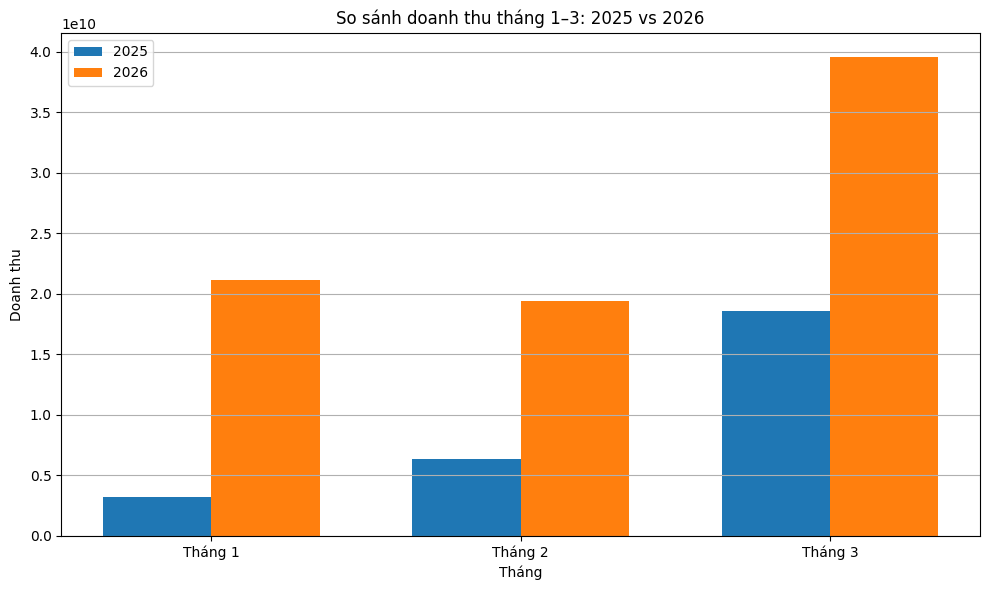

In [29]:
plt.figure(figsize=(10, 6))

x = np.arange(len(pivot_month["month"]))
width = 0.35

plt.bar(x - width/2, pivot_month["revenue_2025"], width, label="2025")
plt.bar(x + width/2, pivot_month["revenue_2026"], width, label="2026")

plt.xticks(x, ["Tháng 1", "Tháng 2", "Tháng 3"])
plt.title("So sánh doanh thu tháng 1–3: 2025 vs 2026")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

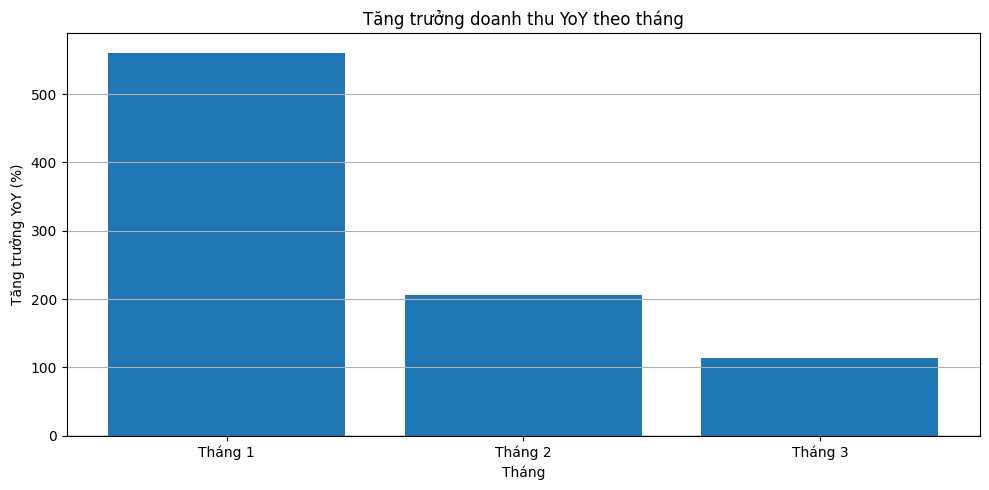

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(["Tháng 1", "Tháng 2", "Tháng 3"], pivot_month["yoy_growth_%"])

plt.axhline(0, linewidth=1)
plt.title("Tăng trưởng doanh thu YoY theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tăng trưởng YoY (%)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [30]:
q1_summary = (
    q1_df
    .groupby("year")
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique"),
        active_dealers=("customer_code", "nunique")
    )
    .reset_index()
)

revenue_2025 = q1_summary.loc[q1_summary["year"] == 2025, "revenue"].values[0]
revenue_2026 = q1_summary.loc[q1_summary["year"] == 2026, "revenue"].values[0]

q1_yoy_growth = (revenue_2026 - revenue_2025) / revenue_2025 * 100

print(q1_summary)
print(f"Tăng trưởng doanh thu Q1/2026 so với Q1/2025: {q1_yoy_growth:.2f}%")

   year       revenue  quantity  order_count  active_dealers
0  2025  2.811717e+10   21476.0          693             333
1  2026  8.012390e+10   50021.0         2026             514
Tăng trưởng doanh thu Q1/2026 so với Q1/2025: 184.96%


In [31]:
q1_compare = q1_summary.set_index("year").T
q1_compare.columns = ["value_2025", "value_2026"]

q1_compare["diff"] = q1_compare["value_2026"] - q1_compare["value_2025"]
q1_compare["growth_%"] = q1_compare["diff"] / q1_compare["value_2025"] * 100

print(q1_compare)

                  value_2025    value_2026          diff    growth_%
revenue         2.811717e+10  8.012390e+10  5.200673e+10  184.964293
quantity        2.147600e+04  5.002100e+04  2.854500e+04  132.915813
order_count     6.930000e+02  2.026000e+03  1.333000e+03  192.352092
active_dealers  3.330000e+02  5.140000e+02  1.810000e+02   54.354354


# 2. Tổng hợp doanh số theo tuần

In [32]:
weekly_q1 = (
    q1_df
    .set_index("order_date")
    .resample("W-MON")
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique"),
        active_dealers=("customer_code", "nunique")
    )
    .reset_index()
)

weekly_q1["year"] = weekly_q1["order_date"].dt.year
weekly_q1["week"] = weekly_q1["order_date"].dt.isocalendar().week.astype(int)

display(weekly_q1)

,order_date,revenue,quantity,order_count,active_dealers,year,week
0,2025-01-06,2.048148e+07,8.0,4,4,2025,2
1,2025-01-13,1.661759e+09,1030.0,32,23,2025,3
2,2025-01-20,9.706857e+08,513.0,16,14,2025,4
3,2025-01-27,5.452438e+08,286.0,9,9,2025,5
4,2025-02-03,0.000000e+00,0.0,0,0,2025,6
...,...,...,...,...,...,...,...
61,2026-03-09,9.775773e+09,6140.0,179,138,2026,11
62,2026-03-16,9.532919e+09,6033.0,202,150,2026,12
63,2026-03-23,7.340657e+09,4801.0,200,125,2026,13
64,2026-03-30,8.197046e+09,5057.0,367,162,2026,14


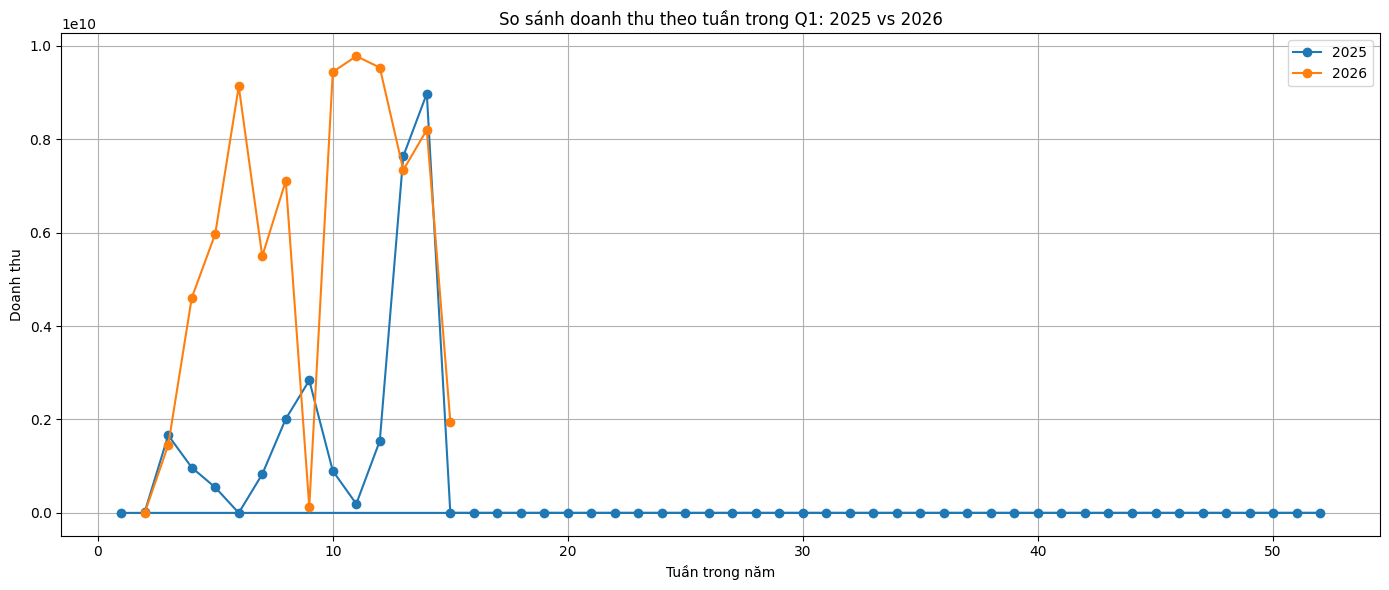

In [17]:
plt.figure(figsize=(14, 6))

for y in [2025, 2026]:
    temp = weekly_q1[weekly_q1["year"] == y]
    plt.plot(
        temp["week"],
        temp["revenue"],
        marker="o",
        label=str(y)
    )

plt.title("So sánh doanh thu theo tuần trong Q1: 2025 vs 2026")
plt.xlabel("Tuần trong năm")
plt.ylabel("Doanh thu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Phân tích theo nhóm sản phẩm

In [33]:
group_q1 = (
    q1_df
    .groupby(["year", "group_name"])
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique")
    )
    .reset_index()
)

group_pivot = group_q1.pivot(
    index="group_name",
    columns="year",
    values="revenue"
).fillna(0).reset_index()

group_pivot.columns.name = None
group_pivot = group_pivot.rename(columns={
    2025: "revenue_2025",
    2026: "revenue_2026"
})

group_pivot["diff_revenue"] = group_pivot["revenue_2026"] - group_pivot["revenue_2025"]
group_pivot["growth_%"] = np.where(
    group_pivot["revenue_2025"] > 0,
    group_pivot["diff_revenue"] / group_pivot["revenue_2025"] * 100,
    np.nan
)

group_pivot = group_pivot.sort_values("diff_revenue", ascending=False)

display(group_pivot)

,group_name,revenue_2025,revenue_2026,diff_revenue,growth_%
0,Xe phổ thông,1.695689e+10,4.208706e+10,2.513017e+10,148.200362
3,Xe trẻ em nhóm 1,4.016083e+09,8.208155e+09,4.192072e+09,104.382119
4,Xe trẻ em nhóm 2,1.899900e+09,3.672639e+09,1.772740e+09,93.307015
2,Xe thể thao thép,2.613696e+09,1.622369e+09,-9.913269e+08,-37.928169
1,Xe thể thao nhôm,2.289778e+09,7.964883e+08,-1.493290e+09,-65.215484


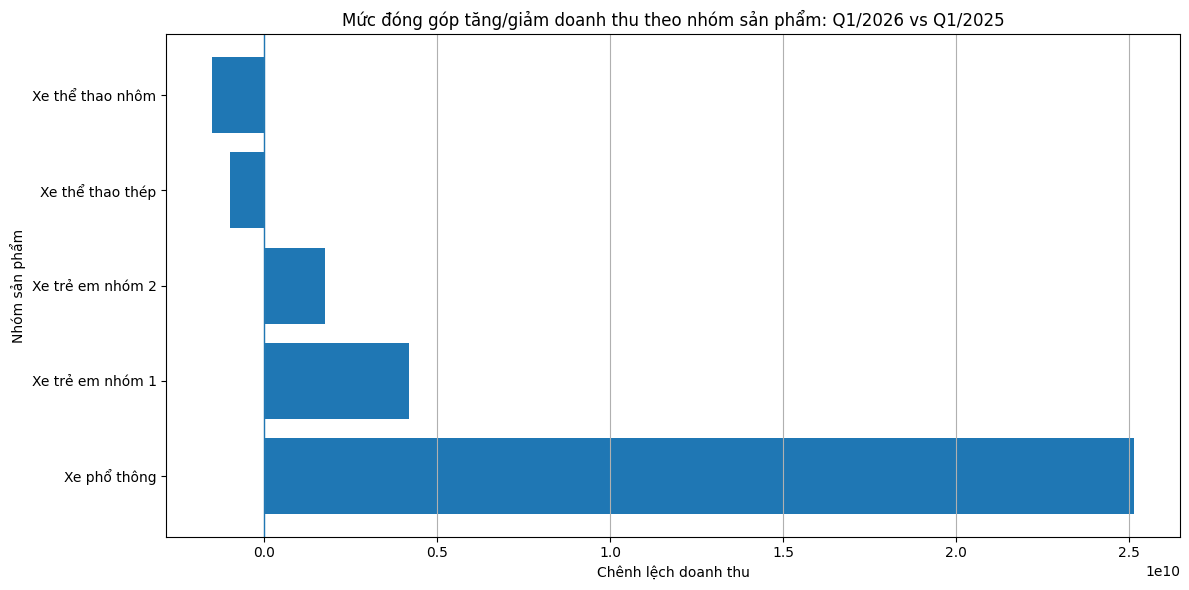

In [20]:
plt.figure(figsize=(12, 6))

plt.barh(group_pivot["group_name"], group_pivot["diff_revenue"])
plt.axvline(0, linewidth=1)

plt.title("Mức đóng góp tăng/giảm doanh thu theo nhóm sản phẩm: Q1/2026 vs Q1/2025")
plt.xlabel("Chênh lệch doanh thu")
plt.ylabel("Nhóm sản phẩm")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

# 4. Waterfal

In [34]:
# =========================
# WATERFALL: Q1/2025 -> Q1/2026
# =========================

group_q1 = (
    q1_df
    .groupby(["fiscal_year", "group_name"])
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique")
    )
    .reset_index()
)

group_pivot = group_q1.pivot(
    index="group_name",
    columns="fiscal_year",
    values="revenue"
).fillna(0)

group_pivot.columns = ["revenue_2025", "revenue_2026"]

group_pivot["diff_revenue"] = group_pivot["revenue_2026"] - group_pivot["revenue_2025"]
group_pivot = group_pivot.sort_values("diff_revenue", ascending=False)

revenue_2025 = q1_df.loc[q1_df["fiscal_year"] == 2025, "line_total"].sum()
revenue_2026 = q1_df.loc[q1_df["fiscal_year"] == 2026, "line_total"].sum()

print("Doanh thu Q1/2025:", f"{revenue_2025:,.0f}")
print("Doanh thu Q1/2026:", f"{revenue_2026:,.0f}")
display(group_pivot)

Doanh thu Q1/2025: 28,117,171,563
Doanh thu Q1/2026: 80,123,899,090


,revenue_2025,revenue_2026,diff_revenue
group_name,,,
Xe phổ thông,1.695689e+10,4.208706e+10,2.513017e+10
Xe trẻ em nhóm 1,4.016083e+09,8.208155e+09,4.192072e+09
Xe trẻ em nhóm 2,1.899900e+09,3.672639e+09,1.772740e+09
Xe thể thao thép,2.613696e+09,1.622369e+09,-9.913269e+08
Xe thể thao nhôm,2.289778e+09,7.964883e+08,-1.493290e+09


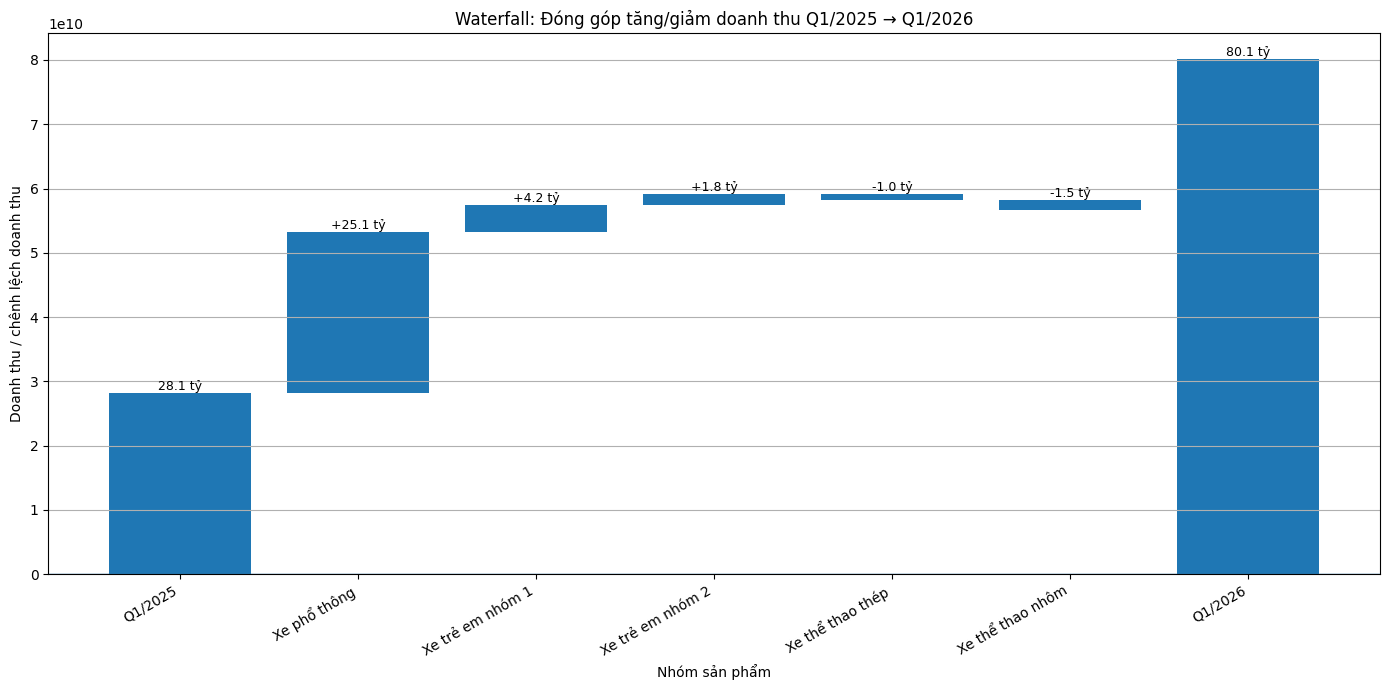

In [22]:
# =========================
# VẼ WATERFALL CHART
# =========================

waterfall_items = ["Q1/2025"] + list(group_pivot.index) + ["Q1/2026"]
waterfall_values = [revenue_2025] + list(group_pivot["diff_revenue"]) + [revenue_2026]

# Tính vị trí đáy của từng cột
bottoms = [0]
running_total = revenue_2025

for diff in group_pivot["diff_revenue"]:
    if diff >= 0:
        bottoms.append(running_total)
    else:
        bottoms.append(running_total + diff)
    running_total += diff

bottoms.append(0)

# Giá trị chiều cao cột
heights = [revenue_2025] + list(abs(group_pivot["diff_revenue"])) + [revenue_2026]

plt.figure(figsize=(14, 7))

bars = plt.bar(
    waterfall_items,
    heights,
    bottom=bottoms
)

plt.axhline(0, linewidth=1)

# Thêm nhãn số
for i, (item, height, bottom, value) in enumerate(zip(waterfall_items, heights, bottoms, waterfall_values)):
    if item in ["Q1/2025", "Q1/2026"]:
        label = f"{value/1e9:.1f} tỷ"
        y = bottom + height
    else:
        sign = "+" if value >= 0 else "-"
        label = f"{sign}{abs(value)/1e9:.1f} tỷ"
        y = bottom + height

    plt.text(
        i,
        y,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

plt.title("Waterfall: Đóng góp tăng/giảm doanh thu Q1/2025 → Q1/2026")
plt.xlabel("Nhóm sản phẩm")
plt.ylabel("Doanh thu / chênh lệch doanh thu")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# 5. Scatter doanh thu và tăng trưởng sản phẩm

In [35]:
# =========================
# SCATTER: DOANH THU VS TĂNG TRƯỞNG THEO DÒNG SẢN PHẨM
# =========================

line_q1 = (
    q1_df
    .dropna(subset=["line_name"])
    .groupby(["fiscal_year", "group_name", "line_name"])
    .agg(
        revenue=("line_total", "sum"),
        quantity=("quantity", "sum"),
        order_count=("so_number", "nunique")
    )
    .reset_index()
)

line_2025 = line_q1[line_q1["fiscal_year"] == 2025].copy()
line_2026 = line_q1[line_q1["fiscal_year"] == 2026].copy()

line_compare = pd.merge(
    line_2026,
    line_2025[["line_name", "revenue", "quantity", "order_count"]],
    on="line_name",
    how="left",
    suffixes=("_2026", "_2025")
)

line_compare["revenue_2025"] = line_compare["revenue_2025"].fillna(0)
line_compare["quantity_2025"] = line_compare["quantity_2025"].fillna(0)
line_compare["order_count_2025"] = line_compare["order_count_2025"].fillna(0)

line_compare["diff_revenue"] = line_compare["revenue_2026"] - line_compare["revenue_2025"]

line_compare["growth_%"] = np.where(
    line_compare["revenue_2025"] > 0,
    line_compare["diff_revenue"] / line_compare["revenue_2025"] * 100,
    np.nan
)

# Loại các dòng không có doanh thu 2025 để tránh growth % vô cực
scatter_df = line_compare[
    (line_compare["revenue_2025"] > 0) &
    (line_compare["revenue_2026"] > 0)
].copy()

print(scatter_df.sort_values("growth_%", ascending=False).head(20))

    fiscal_year        group_name         line_name  revenue_2026  \
11         2026      Xe phổ thông          Xe LD 26  4.264979e+09   
6          2026      Xe phổ thông   Xe GN 06-24 2.0  2.221193e+09   
16         2026      Xe phổ thông             Xe Nữ  1.829782e+09   
42         2026  Xe trẻ em nhóm 2       Xe Bunny 16  8.652104e+08   
44         2026  Xe trẻ em nhóm 2        Xe Love 16  3.559865e+08   
8          2026      Xe phổ thông   Xe GN 06-26 2.0  4.269028e+09   
38         2026  Xe trẻ em nhóm 1       Xe Puppy 20  3.904283e+09   
45         2026  Xe trẻ em nhóm 2       Xe Robot 16  3.005151e+08   
32         2026  Xe trẻ em nhóm 1  Xe GN 06 20 2024  2.255531e+09   
41         2026  Xe trẻ em nhóm 2       Xe Bunny 12  2.148078e+08   
10         2026      Xe phổ thông  Xe LD 24-01_2023  4.225101e+09   
14         2026      Xe phổ thông         Xe New 24  6.749803e+09   
2          2026      Xe phổ thông         Xe 219-26  1.503736e+09   
3          2026      Xe phổ thông 

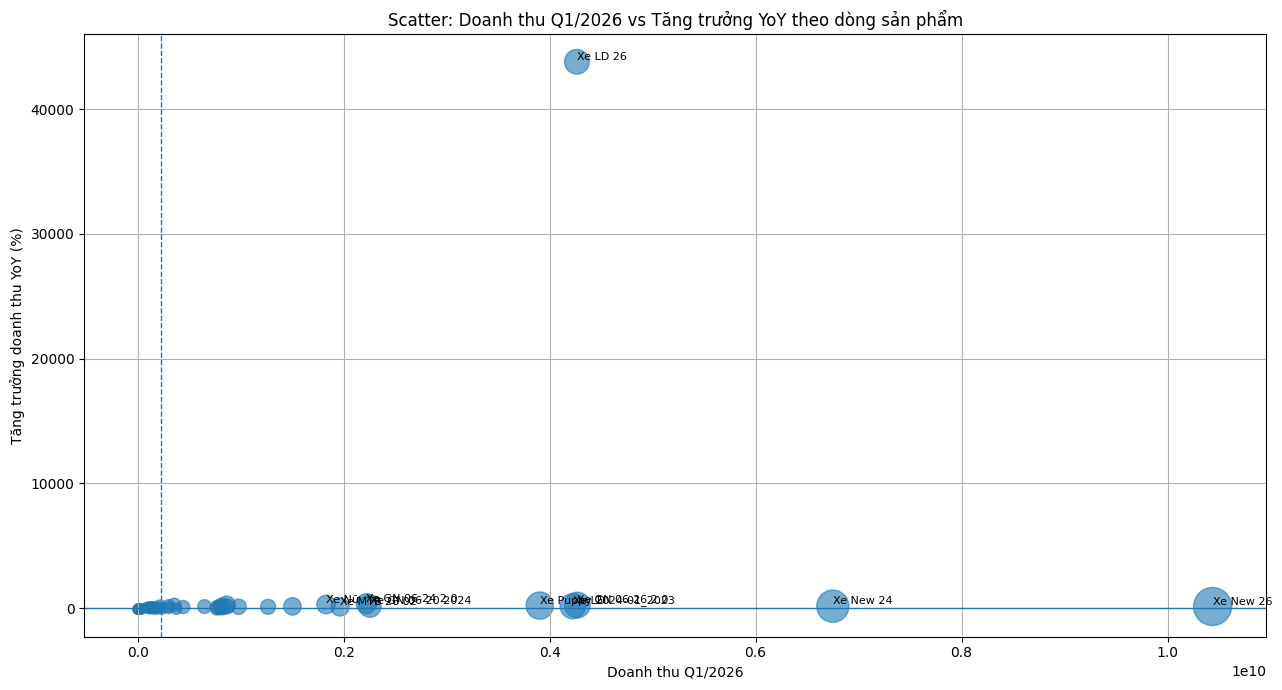

In [36]:
plt.figure(figsize=(13, 7))

size = scatter_df["quantity_2026"]
size_scaled = 50 + (size / size.max()) * 700

plt.scatter(
    scatter_df["revenue_2026"],
    scatter_df["growth_%"],
    s=size_scaled,
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(scatter_df["revenue_2026"].median(), linestyle="--", linewidth=1)

plt.title("Scatter: Doanh thu Q1/2026 vs Tăng trưởng YoY theo dòng sản phẩm")
plt.xlabel("Doanh thu Q1/2026")
plt.ylabel("Tăng trưởng doanh thu YoY (%)")
plt.grid(True)

top_label = scatter_df.sort_values("revenue_2026", ascending=False).head(10)

for _, row in top_label.iterrows():
    plt.text(
        row["revenue_2026"],
        row["growth_%"],
        row["line_name"],
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [38]:
# =========================
# PHÂN LOẠI DÒNG SẢN PHẨM
# =========================

revenue_median = scatter_df["revenue_2026"].median()

def classify_product(row):
    if row["revenue_2026"] >= revenue_median and row["growth_%"] >= 0:
        return "Chủ lực đang tăng"
    elif row["revenue_2026"] >= revenue_median and row["growth_%"] < 0:
        return "Chủ lực chậm lại"
    elif row["revenue_2026"] < revenue_median and row["growth_%"] >= 0:
        return "Tiềm năng tăng trưởng"
    else:
        return "Yếu / suy giảm"

scatter_df["product_status"] = scatter_df.apply(classify_product, axis=1)

status_summary = (
    scatter_df
    .groupby("product_status")
    .agg(
        line_count=("line_name", "nunique"),
        total_revenue_2026=("revenue_2026", "sum"),
        avg_growth=("growth_%", "mean")
    )
    .reset_index()
    .sort_values("total_revenue_2026", ascending=False)
)

print(status_summary)

          product_status  line_count  total_revenue_2026   avg_growth
1      Chủ lực đang tăng          24        5.284176e+10  1970.082767
2  Tiềm năng tăng trưởng          10        1.499910e+09    55.455676
3         Yếu / suy giảm          16        6.114495e+08   -73.246688
0       Chủ lực chậm lại           2        6.107047e+08   -45.606212


In [39]:
# Xem các dòng chủ lực đang tăng
core_growth = scatter_df[
    scatter_df["product_status"] == "Chủ lực đang tăng"
].sort_values("revenue_2026", ascending=False)

print("Dòng chủ lực đang tăng:")
print(core_growth[[
    "group_name",
    "line_name",
    "revenue_2025",
    "revenue_2026",
    "diff_revenue",
    "growth_%",
    "quantity_2026",
    "order_count_2026"
]].head(20))

Dòng chủ lực đang tăng:
          group_name         line_name  revenue_2025  revenue_2026  \
15      Xe phổ thông         Xe New 26  4.595107e+09  1.043644e+10   
14      Xe phổ thông         Xe New 24  2.671549e+09  6.749803e+09   
8       Xe phổ thông   Xe GN 06-26 2.0  1.234008e+09  4.269028e+09   
11      Xe phổ thông          Xe LD 26  9.717500e+06  4.264979e+09   
10      Xe phổ thông  Xe LD 24-01_2023  1.662231e+09  4.225101e+09   
38  Xe trẻ em nhóm 1       Xe Puppy 20  1.303787e+09  3.904283e+09   
32  Xe trẻ em nhóm 1  Xe GN 06 20 2024  8.536500e+08  2.255531e+09   
6       Xe phổ thông   Xe GN 06-24 2.0  4.926694e+08  2.221193e+09   
13      Xe phổ thông      Xe MTB 26 02  1.053002e+09  1.965266e+09   
16      Xe phổ thông             Xe Nữ  4.751500e+08  1.829782e+09   
2       Xe phổ thông         Xe 219-26  6.259449e+08  1.503736e+09   
29  Xe thể thao thép       Xe Super 24  6.188485e+08  1.266339e+09   
7       Xe phổ thông       Xe GN 06-26  4.754144e+08  9.817841e+08

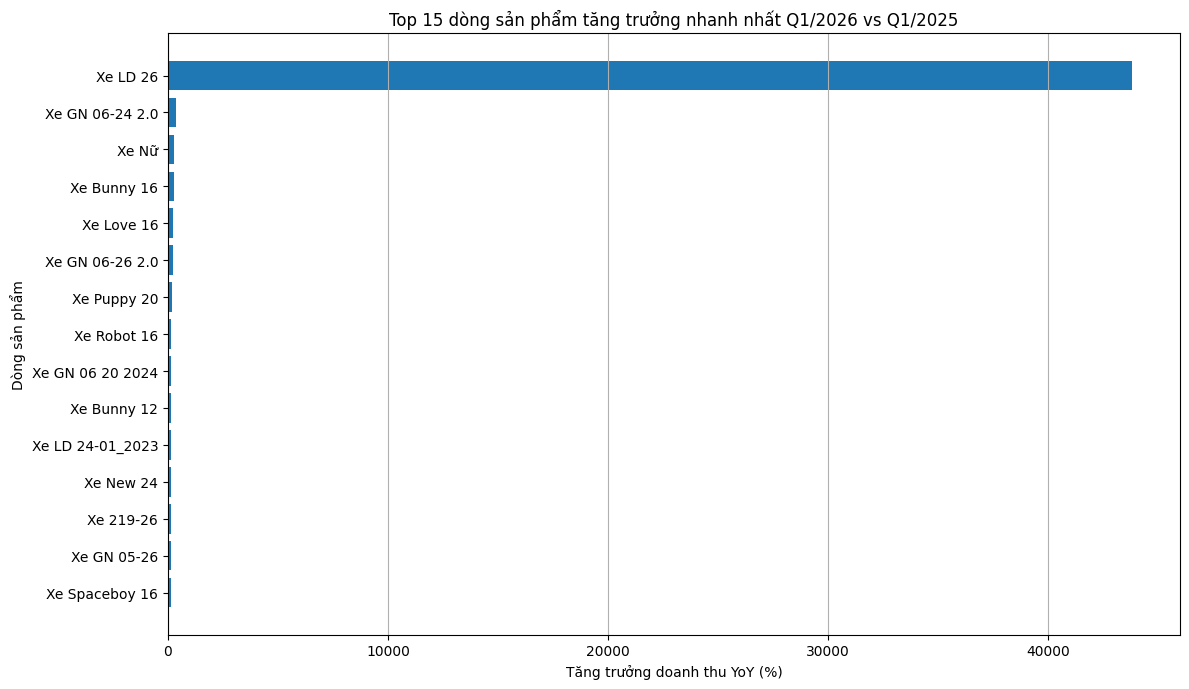

In [40]:
top_growth = scatter_df.sort_values("growth_%", ascending=False).head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_growth["line_name"],
    top_growth["growth_%"]
)

plt.title("Top 15 dòng sản phẩm tăng trưởng nhanh nhất Q1/2026 vs Q1/2025")
plt.xlabel("Tăng trưởng doanh thu YoY (%)")
plt.ylabel("Dòng sản phẩm")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

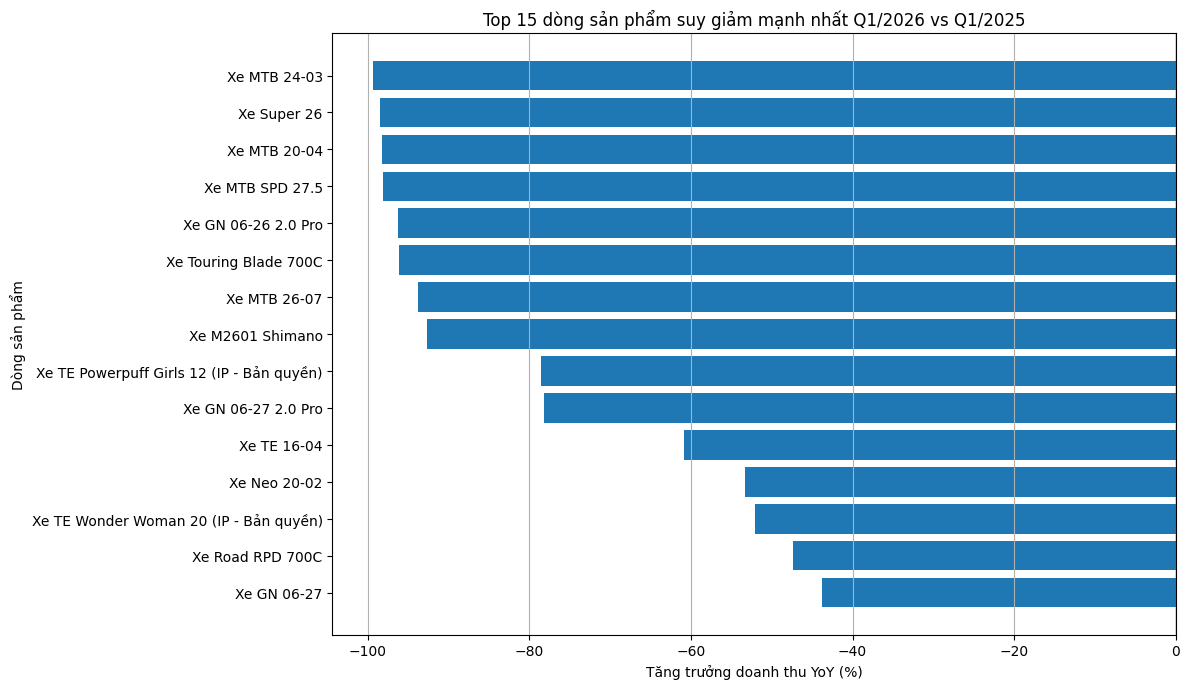

In [41]:
slow_lines = scatter_df.sort_values("growth_%", ascending=True).head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    slow_lines["line_name"],
    slow_lines["growth_%"]
)

plt.axvline(0, linewidth=1)
plt.title("Top 15 dòng sản phẩm suy giảm mạnh nhất Q1/2026 vs Q1/2025")
plt.xlabel("Tăng trưởng doanh thu YoY (%)")
plt.ylabel("Dòng sản phẩm")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

# 6. Phân khúc giá sản phẩm

In [2]:
# =========================
# 2. TIỀN XỬ LÝ GIÁ
# =========================

df_price = df.copy()

# Ép kiểu số
df_price["line_total"] = pd.to_numeric(df_price["line_total"], errors="coerce")
df_price["quantity"] = pd.to_numeric(df_price["quantity"], errors="coerce")

# Loại dòng lỗi
df_price = df_price[
    (df_price["line_total"].notna()) &
    (df_price["quantity"].notna()) &
    (df_price["quantity"] > 0) &
    (df_price["line_total"] > 0)
].copy()

# Vì query chưa có unit_price, tính giá thực tế theo dòng
df_price["unit_price_est"] = df_price["line_total"] / df_price["quantity"]

# Quy đổi sang triệu đồng để dễ đọc
df_price["unit_price_million"] = df_price["unit_price_est"] / 1_000_000
df_price["revenue_billion"] = df_price["line_total"] / 1_000_000_000

In [3]:
# =========================
# 3. THỐNG KÊ GIÁ THEO NHÓM SẢN PHẨM
# =========================

price_summary_by_group = (
    df_price
    .groupby("group_name")
    .agg(
        sku_count=("product_code", "nunique"),
        order_count=("so_number", "nunique"),
        total_qty=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        min_price=("unit_price_est", "min"),
        q25_price=("unit_price_est", lambda x: x.quantile(0.25)),
        median_price=("unit_price_est", "median"),
        avg_price=("unit_price_est", "mean"),
        q75_price=("unit_price_est", lambda x: x.quantile(0.75)),
        max_price=("unit_price_est", "max")
    )
    .reset_index()
)

# Format sang triệu đồng
price_cols = ["min_price", "q25_price", "median_price", "avg_price", "q75_price", "max_price"]

for col in price_cols:
    price_summary_by_group[col + "_trieu"] = price_summary_by_group[col] / 1_000_000

price_summary_by_group["total_revenue_ty"] = price_summary_by_group["total_revenue"] / 1_000_000_000

display_cols = [
    "group_name",
    "sku_count",
    "order_count",
    "total_qty",
    "total_revenue_ty",
    "min_price_trieu",
    "q25_price_trieu",
    "median_price_trieu",
    "avg_price_trieu",
    "q75_price_trieu",
    "max_price_trieu"
]

price_summary_by_group[display_cols].sort_values("avg_price_trieu", ascending=False)

,group_name,sku_count,order_count,total_qty,total_revenue_ty,min_price_trieu,q25_price_trieu,median_price_trieu,avg_price_trieu,q75_price_trieu,max_price_trieu
1,Xe thể thao nhôm,17,267,1144.0,3.086267,1.260000,2.15,2.150000,2.640740,3.222643,7.490741
2,Xe thể thao thép,34,468,2277.0,4.236064,1.030000,1.30,1.900000,1.820597,2.118888,4.157407
0,Xe phổ thông,65,2265,39697.0,59.043956,1.086111,1.20,1.555000,1.487511,1.616111,2.953704
3,Xe trẻ em nhóm 1,36,1312,9805.0,12.224238,0.750000,1.15,1.200000,1.249980,1.310555,2.583333
4,Xe trẻ em nhóm 2,23,751,6204.0,5.572539,0.470000,0.55,0.943888,0.912189,1.133611,2.212963


In [4]:
# =========================
# 4. PHÂN KHÚC GIÁ CỐ ĐỊNH
# =========================

bins = [0, 1_000_000, 1_500_000, 2_500_000, np.inf]
labels = [
    "Giá thấp (<1 triệu)",
    "Trung bình (1–1.5 triệu)",
    "Cao (1.5–2.5 triệu)",
    "Premium (>2.5 triệu)"
]

df_price["price_segment"] = pd.cut(
    df_price["unit_price_est"],
    bins=bins,
    labels=labels,
    right=False
)

segment_by_group = (
    df_price
    .groupby(["group_name", "price_segment"], observed=False)
    .agg(
        sku_count=("product_code", "nunique"),
        total_qty=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        avg_price=("unit_price_est", "mean")
    )
    .reset_index()
)

segment_by_group["revenue_share_in_group"] = (
    segment_by_group["total_revenue"] /
    segment_by_group.groupby("group_name")["total_revenue"].transform("sum")
)

segment_by_group["total_revenue_ty"] = segment_by_group["total_revenue"] / 1_000_000_000
segment_by_group["avg_price_trieu"] = segment_by_group["avg_price"] / 1_000_000
segment_by_group["revenue_share_pct"] = segment_by_group["revenue_share_in_group"] * 100

segment_by_group.sort_values(["group_name", "total_revenue"], ascending=[True, False])

,group_name,price_segment,sku_count,total_qty,total_revenue,avg_price,revenue_share_in_group,total_revenue_ty,avg_price_trieu,revenue_share_pct
2,Xe phổ thông,Cao (1.5–2.5 triệu),60,23590.0,3.906352e+10,1.651767e+06,0.661601,39.063524,1.651767,66.160074
1,Xe phổ thông,Trung bình (1–1.5 triệu),61,16040.0,1.980055e+10,1.233245e+06,0.335353,19.800554,1.233245,33.535277
3,Xe phổ thông,Premium (>2.5 triệu),18,67.0,1.798773e+08,2.692816e+06,0.003046,0.179877,2.692816,0.304650
0,Xe phổ thông,Giá thấp (<1 triệu),0,0.0,0.000000e+00,NaN,0.000000,0.000000,NaN,0.000000
7,Xe thể thao nhôm,Premium (>2.5 triệu),16,592.0,1.925657e+09,3.273510e+06,0.623944,1.925657,3.273510,62.394370
6,Xe thể thao nhôm,Cao (1.5–2.5 triệu),11,520.0,1.116650e+09,2.158444e+06,0.361813,1.116650,2.158444,36.181255
5,Xe thể thao nhôm,Trung bình (1–1.5 triệu),4,32.0,4.396000e+07,1.370000e+06,0.014244,0.043960,1.370000,1.424375
4,Xe thể thao nhôm,Giá thấp (<1 triệu),0,0.0,0.000000e+00,NaN,0.000000,0.000000,NaN,0.000000
10,Xe thể thao thép,Cao (1.5–2.5 triệu),25,773.0,1.733302e+09,2.193794e+06,0.409177,1.733302,2.193794,40.917735
9,Xe thể thao thép,Trung bình (1–1.5 triệu),24,1110.0,1.417230e+09,1.273002e+06,0.334563,1.417230,1.273002,33.456291


In [5]:
# =========================
# 5. MA TRẬN TỶ TRỌNG DOANH THU THEO PHÂN KHÚC GIÁ
# =========================

price_segment_matrix = segment_by_group.pivot_table(
    index="group_name",
    columns="price_segment",
    values="revenue_share_pct",
    aggfunc="sum",
    fill_value=0,
    observed=False
)

price_segment_matrix.round(2)

price_segment,Giá thấp (<1 triệu),Trung bình (1–1.5 triệu),Cao (1.5–2.5 triệu),Premium (>2.5 triệu)
group_name,,,,
Xe phổ thông,0.00,33.54,66.16,0.30
Xe thể thao nhôm,0.00,1.42,36.18,62.39
Xe thể thao thép,0.00,33.46,40.92,25.63
Xe trẻ em nhóm 1,0.13,84.60,15.25,0.02
Xe trẻ em nhóm 2,56.88,41.17,1.95,0.00


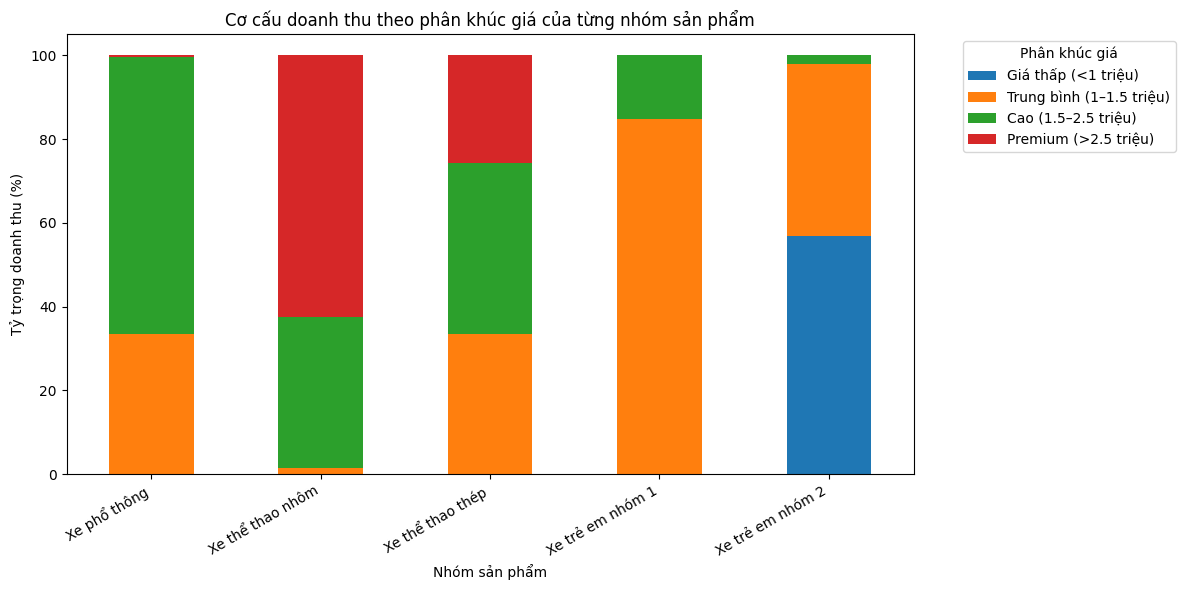

In [6]:
# =========================
# 6. BIỂU ĐỒ STACKED BAR
# =========================

plot_data = price_segment_matrix.copy()

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Cơ cấu doanh thu theo phân khúc giá của từng nhóm sản phẩm")
plt.xlabel("Nhóm sản phẩm")
plt.ylabel("Tỷ trọng doanh thu (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Phân khúc giá", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 7. Biến động giá

In [7]:
# =========================
# 1. QUERY LỊCH SỬ GIÁ SẢN PHẨM
# =========================

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="tnbike_db",
    user="postgres",
    password="postgres"
)

query_price = """
SELECT
    pp.product_code,
    p.product_name,
    p.color,
    pl.line_name,
    pg.group_name,
    pp.unit_price,
    pp.effective_from,
    pp.effective_to
FROM tnbike.product_price pp
LEFT JOIN tnbike.product p
    ON pp.product_code = p.product_code
LEFT JOIN tnbike.product_line pl
    ON p.line_id = pl.line_id
LEFT JOIN tnbike.product_group pg
    ON pl.group_code = pg.group_code
ORDER BY pp.product_code, pp.effective_from;
"""

df_price_hist = pd.read_sql(query_price, conn)
conn.close()

df_price_hist["effective_from"] = pd.to_datetime(df_price_hist["effective_from"])
df_price_hist["effective_to"] = pd.to_datetime(df_price_hist["effective_to"])
df_price_hist["unit_price"] = pd.to_numeric(df_price_hist["unit_price"], errors="coerce")

df_price_hist.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6708\2722017169.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_price_hist = pd.read_sql(query_price, conn)


,product_code,product_name,color,line_name,group_name,unit_price,effective_from,effective_to
0,000102002009000,Xe đạp Thống Nhất We Bare Bears 12 Hồng,Hồng,None,None,1146296.0,2026-01-24,NaT
1,000102002009000,Xe đạp Thống Nhất We Bare Bears 12 Hồng,Hồng,None,None,470000.0,2026-01-27,NaT
2,000102002009000,Xe đạp Thống Nhất We Bare Bears 12 Hồng,Hồng,None,None,1132407.0,2026-02-04,NaT
3,000102002023000,Xe đạp Thống Nhất We Bare Bears 12 Kem,Kem,None,None,1146296.0,2026-01-12,NaT
4,000102002023000,Xe đạp Thống Nhất We Bare Bears 12 Kem,Kem,None,None,1132407.0,2026-02-06,NaT


In [8]:
# =========================
# 2. TỔNG QUAN LỊCH SỬ GIÁ
# =========================

price_overview = (
    df_price_hist
    .groupby(["group_name"])
    .agg(
        sku_count=("product_code", "nunique"),
        price_record_count=("unit_price", "count"),
        avg_price=("unit_price", "mean"),
        min_price=("unit_price", "min"),
        max_price=("unit_price", "max"),
        median_price=("unit_price", "median")
    )
    .reset_index()
)

price_overview["avg_price_trieu"] = price_overview["avg_price"] / 1_000_000
price_overview["min_price_trieu"] = price_overview["min_price"] / 1_000_000
price_overview["max_price_trieu"] = price_overview["max_price"] / 1_000_000
price_overview["median_price_trieu"] = price_overview["median_price"] / 1_000_000
price_overview["price_range_trieu"] = price_overview["max_price_trieu"] - price_overview["min_price_trieu"]

price_overview[
    [
        "group_name",
        "sku_count",
        "price_record_count",
        "avg_price_trieu",
        "median_price_trieu",
        "min_price_trieu",
        "max_price_trieu",
        "price_range_trieu"
    ]
].sort_values("avg_price_trieu", ascending=False)

,group_name,sku_count,price_record_count,avg_price_trieu,median_price_trieu,min_price_trieu,max_price_trieu,price_range_trieu
1,Xe thể thao nhôm,17,47,3.367290,3.003788,1.600000,7.490741,5.890741
2,Xe thể thao thép,34,90,2.242112,2.393888,1.200000,4.157407,2.957407
0,Xe phổ thông,65,392,1.705979,1.618981,1.086111,2.798611,1.712500
3,Xe trẻ em nhóm 1,36,146,1.355291,1.310555,0.750000,2.407407,1.657407
4,Xe trẻ em nhóm 2,23,127,1.125403,1.133611,0.470000,2.212963,1.742963


In [9]:
# =========================
# 3. BIẾN ĐỘNG GIÁ THEO SKU
# =========================

df_price_sorted = df_price_hist.sort_values(["product_code", "effective_from"]).copy()

sku_price_change = (
    df_price_sorted
    .groupby(["product_code", "product_name", "group_name", "line_name"])
    .agg(
        first_price=("unit_price", "first"),
        last_price=("unit_price", "last"),
        min_price=("unit_price", "min"),
        max_price=("unit_price", "max"),
        price_records=("unit_price", "count"),
        first_date=("effective_from", "first"),
        last_date=("effective_from", "last")
    )
    .reset_index()
)

sku_price_change["abs_change"] = sku_price_change["last_price"] - sku_price_change["first_price"]
sku_price_change["pct_change"] = sku_price_change["abs_change"] / sku_price_change["first_price"] * 100
sku_price_change["range_pct"] = (sku_price_change["max_price"] - sku_price_change["min_price"]) / sku_price_change["min_price"] * 100

# Phân loại hướng biến động
sku_price_change["price_direction"] = np.select(
    [
        sku_price_change["pct_change"] > 5,
        sku_price_change["pct_change"] < -5
    ],
    [
        "Tăng giá rõ",
        "Giảm giá rõ"
    ],
    default="Ổn định / dao động nhẹ"
)

sku_price_change["first_price_trieu"] = sku_price_change["first_price"] / 1_000_000
sku_price_change["last_price_trieu"] = sku_price_change["last_price"] / 1_000_000
sku_price_change["abs_change_trieu"] = sku_price_change["abs_change"] / 1_000_000

sku_price_change.sort_values("pct_change", ascending=False).head(20)

,product_code,product_name,group_name,line_name,first_price,last_price,min_price,max_price,price_records,first_date,last_date,abs_change,pct_change,range_pct,price_direction,first_price_trieu,last_price_trieu,abs_change_trieu
167,1010020000080000,"Xe đạp Thống Nhất GRX AT 27,5_2.0_15 Ghi",Xe thể thao nhôm,"Xe GRX AT 27,5_2.0",2400000.0,7490740.74,2400000.0,7490740.74,2,2025-03-19,2025-03-24,5090740.74,212.114197,212.114197,Tăng giá rõ,2.40,7.490741,5.090741
141,1000240020090000,Xe đạp Thống Nhất TE Bunny 16 Hồng,Xe trẻ em nhóm 2,Xe Bunny 16,500000.0,1472222.00,500000.0,1472222.22,8,2025-01-10,2026-02-24,972222.00,194.444400,194.444444,Tăng giá rõ,0.50,1.472222,0.972222
139,1000220020220000,Xe đạp Thống Nhất TE Love 16 Xanh dương,Xe trẻ em nhóm 2,Xe Love 16,500000.0,1133611.10,500000.0,1133611.11,5,2025-01-10,2026-02-24,633611.10,126.722220,126.722222,Tăng giá rõ,0.50,1.133611,0.633611
146,1000270020150000,Xe đạp Thống Nhất TE Spaceboy 16 Café/nâu,Xe trẻ em nhóm 2,Xe Spaceboy 16,500000.0,1133611.10,500000.0,1148333.00,7,2025-01-09,2026-02-24,633611.10,126.722220,129.666600,Tăng giá rõ,0.50,1.133611,0.633611
147,1000270020220000,Xe đạp Thống Nhất TE Spaceboy 16 Xanh dương,Xe trẻ em nhóm 2,Xe Spaceboy 16,500000.0,1133611.00,500000.0,1472222.00,8,2025-01-09,2026-02-10,633611.00,126.722200,194.444400,Tăng giá rõ,0.50,1.133611,0.633611
145,1000260020220000,Xe đạp Thống Nhất TE Spaceboy 12 Xanh dương,Xe trẻ em nhóm 2,Xe Spaceboy 12,470000.0,1062314.80,470000.0,1062314.81,6,2025-01-13,2026-02-24,592314.80,126.024426,126.024428,Tăng giá rõ,0.47,1.062315,0.592315
65,000224002002000,Xe đạp Thống Nhất New 24 Trắng,Xe phổ thông,Xe New 24,1130000.0,2398148.00,1130000.0,2398148.00,9,2025-01-10,2026-02-11,1268148.00,112.225487,112.225487,Tăng giá rõ,1.13,2.398148,1.268148
153,1000300050080000,Xe đạp Thống Nhất MTB SPD 27.5 ( Ghi),Xe thể thao nhôm,Xe MTB SPD 27.5,2150000.0,4527778.00,2150000.0,4527778.00,2,2025-01-10,2025-01-23,2377778.00,110.594326,110.594326,Tăng giá rõ,2.15,4.527778,2.377778
95,000231003005000,Xe đạp Thống Nhất M2601 Đen Tem cam,Xe thể thao thép,Xe M2601,1200000.0,2401388.00,1200000.0,2401388.00,2,2025-01-18,2025-02-25,1201388.00,100.115667,100.115667,Tăng giá rõ,1.20,2.401388,1.201388
135,000490002007000,Xe đạp đôi Thống Nhất 26 Coban,Xe phổ thông,Xe đạp đôi 26,1400000.0,2798611.00,1400000.0,2798611.00,2,2025-02-10,2025-03-26,1398611.00,99.900786,99.900786,Tăng giá rõ,1.40,2.798611,1.398611


In [10]:
# =========================
# 4. CHIẾN LƯỢC GIÁ THEO NHÓM SẢN PHẨM
# =========================

strategy_by_group = (
    sku_price_change
    .groupby("group_name")
    .agg(
        sku_count=("product_code", "nunique"),
        avg_first_price=("first_price", "mean"),
        avg_last_price=("last_price", "mean"),
        avg_pct_change=("pct_change", "mean"),
        median_pct_change=("pct_change", "median"),
        avg_range_pct=("range_pct", "mean"),
        sku_increased=("price_direction", lambda x: (x == "Tăng giá rõ").sum()),
        sku_decreased=("price_direction", lambda x: (x == "Giảm giá rõ").sum()),
        sku_stable=("price_direction", lambda x: (x == "Ổn định / dao động nhẹ").sum())
    )
    .reset_index()
)

strategy_by_group["avg_first_price_trieu"] = strategy_by_group["avg_first_price"] / 1_000_000
strategy_by_group["avg_last_price_trieu"] = strategy_by_group["avg_last_price"] / 1_000_000
strategy_by_group["increase_ratio_pct"] = strategy_by_group["sku_increased"] / strategy_by_group["sku_count"] * 100
strategy_by_group["decrease_ratio_pct"] = strategy_by_group["sku_decreased"] / strategy_by_group["sku_count"] * 100
strategy_by_group["stable_ratio_pct"] = strategy_by_group["sku_stable"] / strategy_by_group["sku_count"] * 100

strategy_by_group[
    [
        "group_name",
        "sku_count",
        "avg_first_price_trieu",
        "avg_last_price_trieu",
        "avg_pct_change",
        "median_pct_change",
        "avg_range_pct",
        "increase_ratio_pct",
        "decrease_ratio_pct",
        "stable_ratio_pct"
    ]
].sort_values("avg_pct_change", ascending=False)

,group_name,sku_count,avg_first_price_trieu,avg_last_price_trieu,avg_pct_change,median_pct_change,avg_range_pct,increase_ratio_pct,decrease_ratio_pct,stable_ratio_pct
4,Xe trẻ em nhóm 2,23,0.955125,1.188476,52.017720,57.142842,128.831235,60.869565,34.782609,4.347826
0,Xe phổ thông,65,1.464394,1.765954,27.106479,28.030273,74.381116,64.615385,15.384615,20.000000
2,Xe thể thao thép,34,2.039593,2.314849,25.782697,0.000000,75.891184,44.117647,17.647059,38.235294
1,Xe thể thao nhôm,17,3.433120,3.468774,19.217510,10.000000,77.051378,64.705882,23.529412,11.764706
3,Xe trẻ em nhóm 1,36,1.284799,1.356759,10.721311,0.000000,44.594505,47.222222,16.666667,36.111111


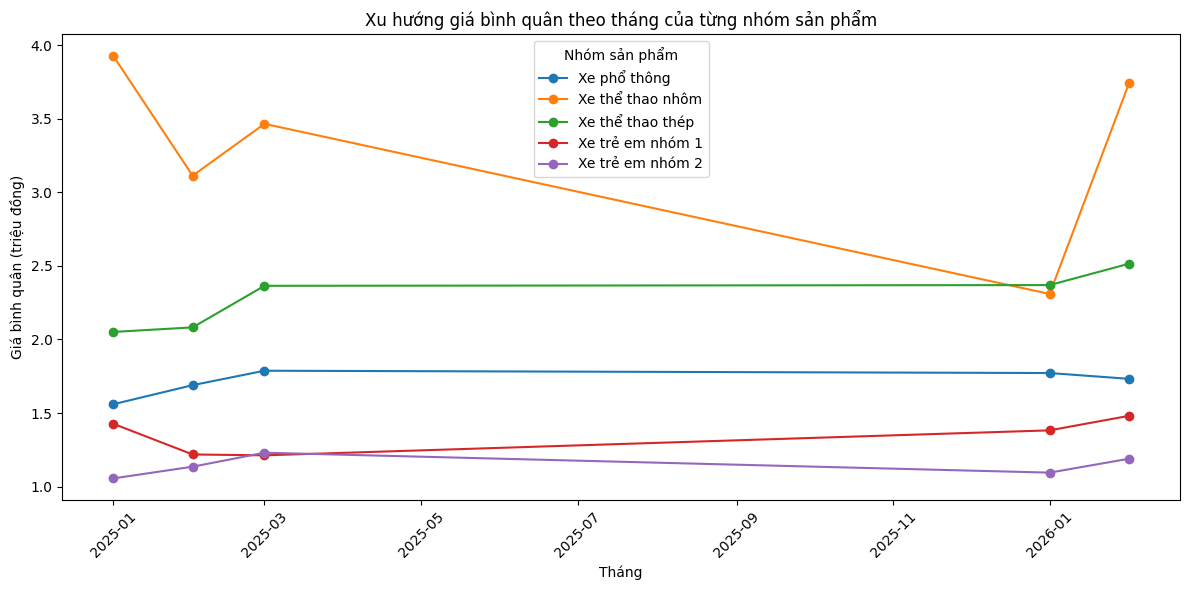

In [11]:
# =========================
# 5. XU HƯỚNG GIÁ BÌNH QUÂN THEO THÁNG
# =========================

df_price_hist["year_month"] = df_price_hist["effective_from"].dt.to_period("M").dt.to_timestamp()

monthly_price_by_group = (
    df_price_hist
    .groupby(["year_month", "group_name"])
    .agg(
        avg_price=("unit_price", "mean"),
        median_price=("unit_price", "median"),
        sku_count=("product_code", "nunique")
    )
    .reset_index()
)

monthly_price_by_group["avg_price_trieu"] = monthly_price_by_group["avg_price"] / 1_000_000
monthly_price_by_group["median_price_trieu"] = monthly_price_by_group["median_price"] / 1_000_000

plt.figure(figsize=(12, 6))

for group in monthly_price_by_group["group_name"].dropna().unique():
    temp = monthly_price_by_group[monthly_price_by_group["group_name"] == group]
    plt.plot(temp["year_month"], temp["avg_price_trieu"], marker="o", label=group)

plt.title("Xu hướng giá bình quân theo tháng của từng nhóm sản phẩm")
plt.xlabel("Tháng")
plt.ylabel("Giá bình quân (triệu đồng)")
plt.xticks(rotation=45)
plt.legend(title="Nhóm sản phẩm")
plt.tight_layout()
plt.show()